# **1.Introduction**
# Project Title:
# Predicting Student Exam Scores Using Regression Models

# Objective:
# The goal of this project is to predict students' exam scores
# based on demographic, lifestyle, behavioral, and academic features.

# Main Tasks:
# 1. Explore the dataset
# 2. Perform hypothesis testing
# 3. Preprocess the data
# 4. Train baseline regression models:
#   - Linear Regression
#   - Ridge Regression
#   - Lasso Regression
# 5. Apply model selection methods:
#   - Forward Selection
#   - Backward Elimination
#   - Hybrid Selection
#   - Best Subset Selection
# 6. Compare all approaches
# 7. Analyze feature importance
# 8. Evaluate bias-variance behavior using learning curves


# **2. Load Dataset**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, kruskal, chi2_contingency

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("student_habits_performance.csv")


In [4]:
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
df.shape


(1000, 16)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [7]:
df.describe()


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


# **3. EDA**

# **3.1 Missing Values**

In [8]:
df.isnull().sum()


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

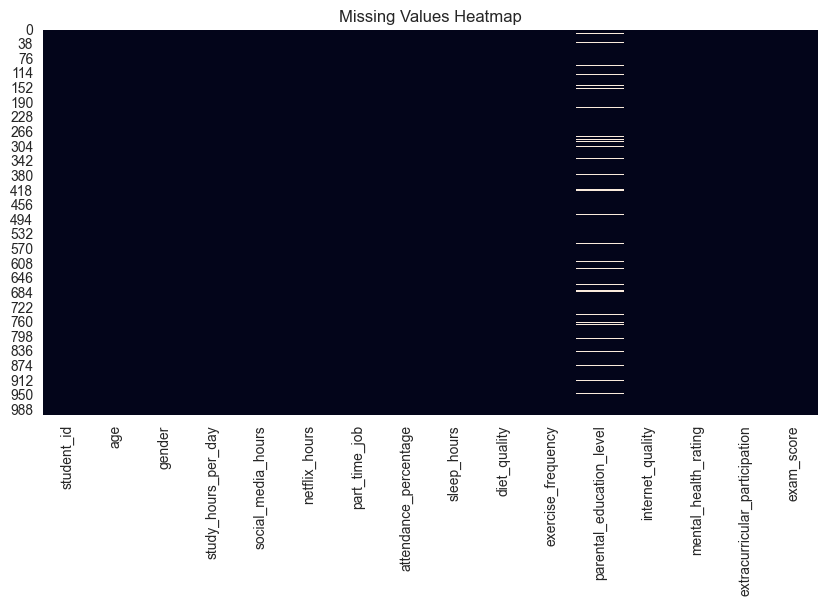

In [9]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


# **3.2 Numeric and Categorical Columns**

In [10]:
numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_all = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols_all)

print("\nCategorical columns:")
print(categorical_cols_all)


Numeric columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical columns:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


# **3.3 Distribution of Target Variable**

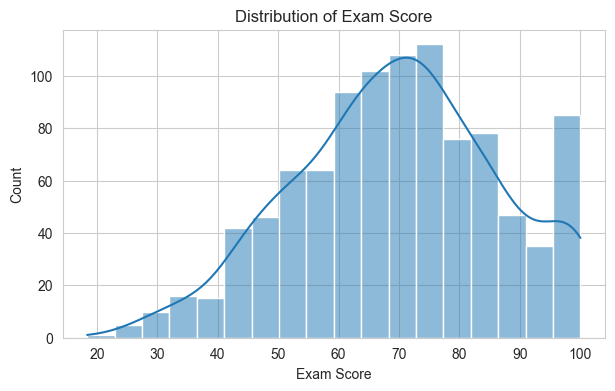

In [11]:
plt.figure(figsize=(7, 4))
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()


# **3.4 Distributions of Numeric Features**

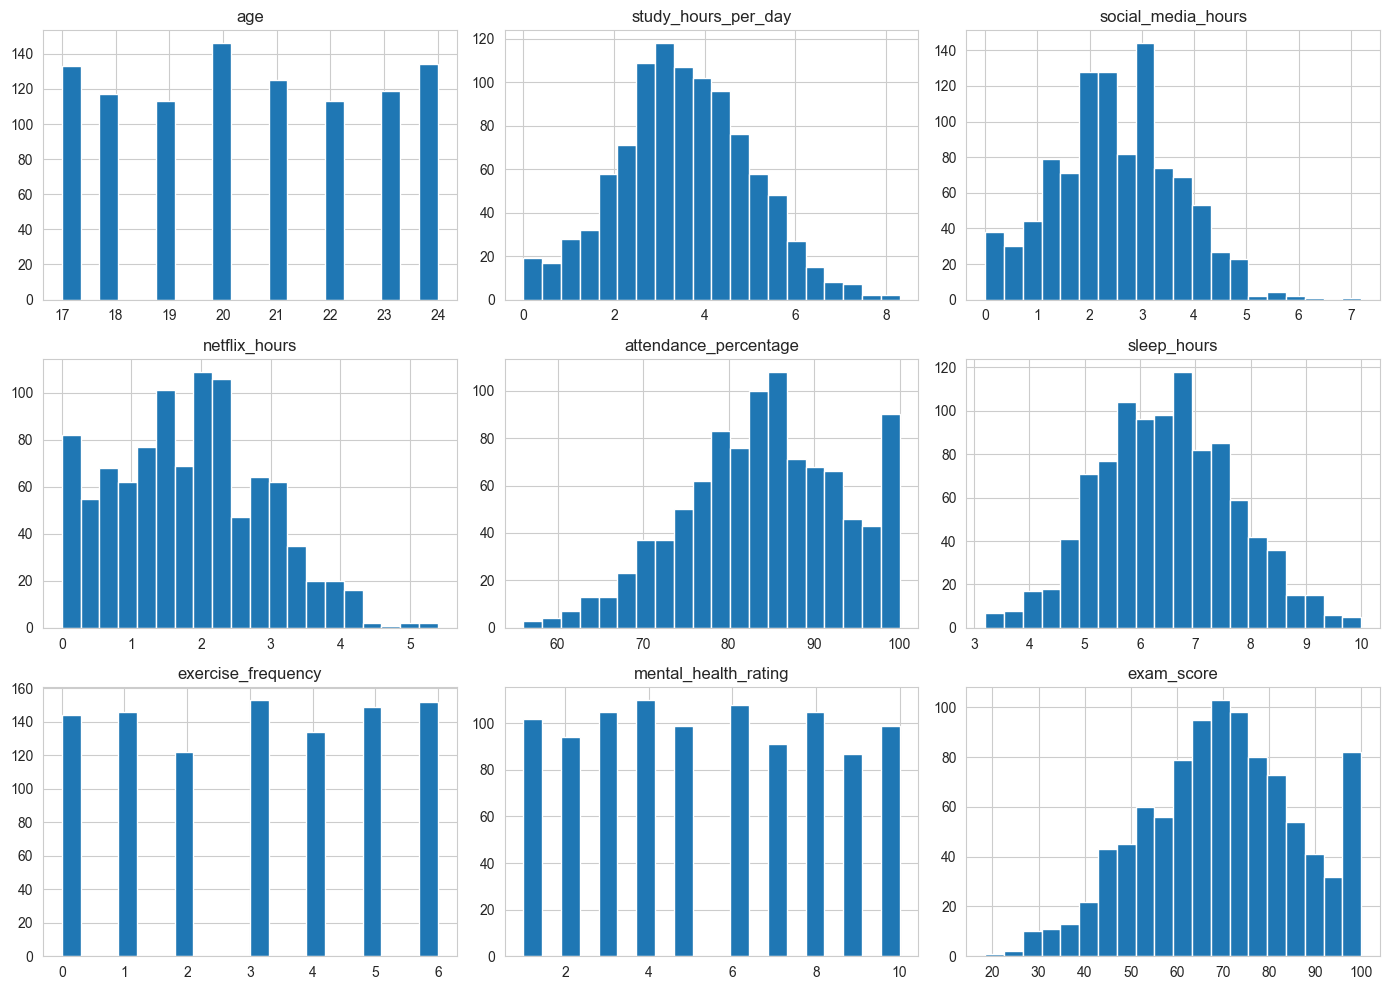

In [12]:
numeric_features_for_plot = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

df[numeric_features_for_plot].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()


# **3.5 Categorical Frequency Distributions**

In [13]:
categorical_features = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]

for col in categorical_features:
    print(col)
    print(df[col].value_counts())
    print("-" * 40)


gender
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64
----------------------------------------
part_time_job
part_time_job
No     785
Yes    215
Name: count, dtype: int64
----------------------------------------
diet_quality
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64
----------------------------------------
parental_education_level
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
----------------------------------------
internet_quality
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64
----------------------------------------
extracurricular_participation
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64
----------------------------------------


# **3.6 Bar Plots for Categorical Variables**

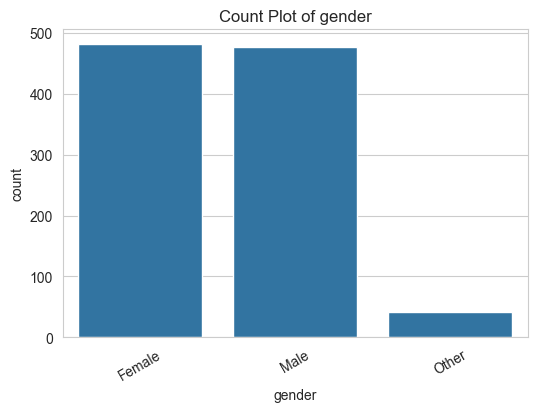

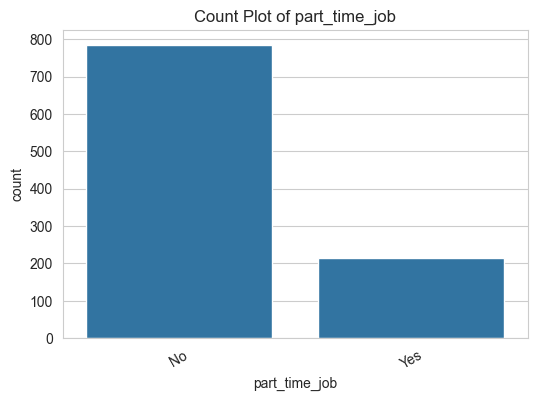

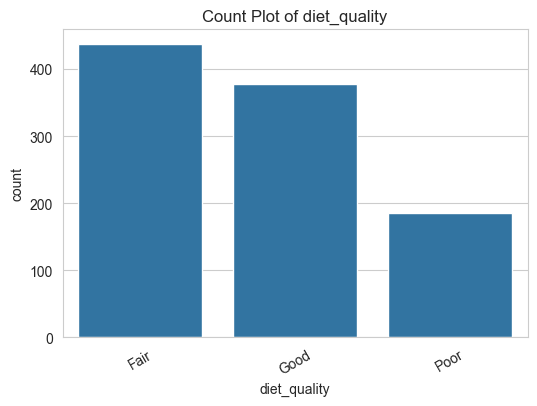

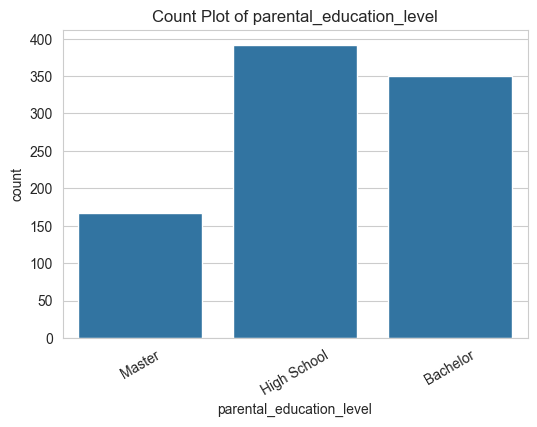

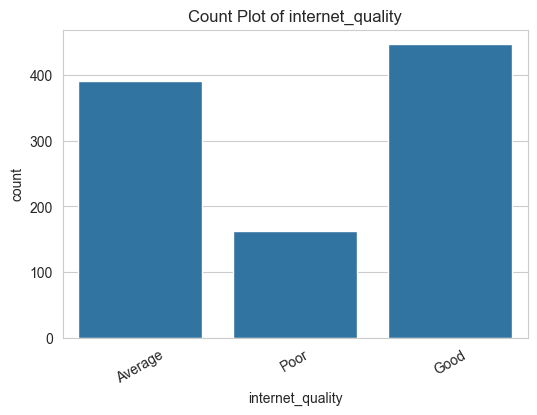

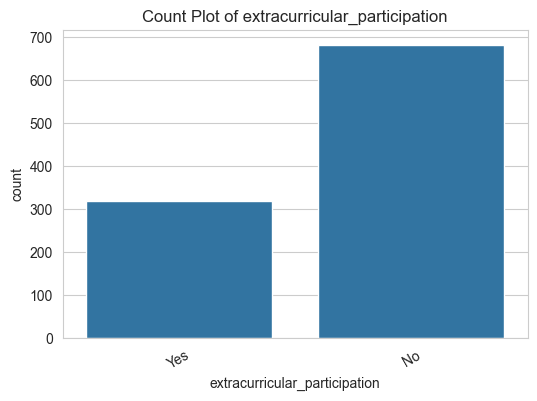

In [14]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=30)
    plt.show()


# **3.7 Scatter Plots with Exam Score**

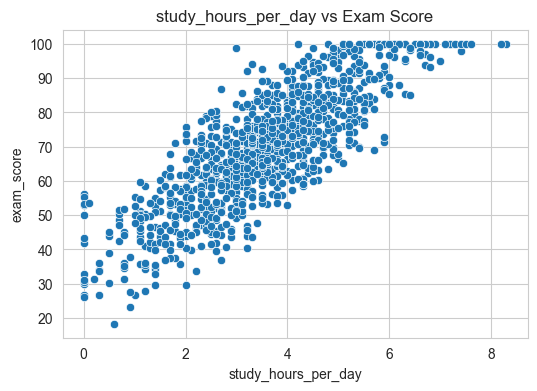

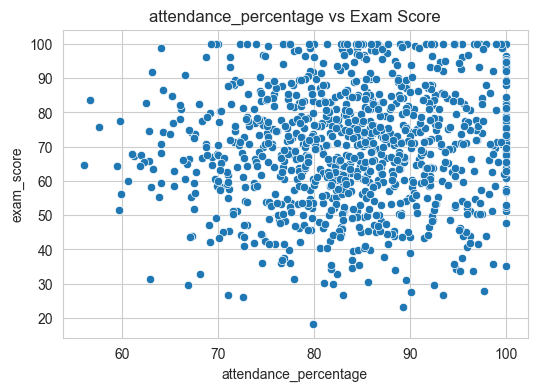

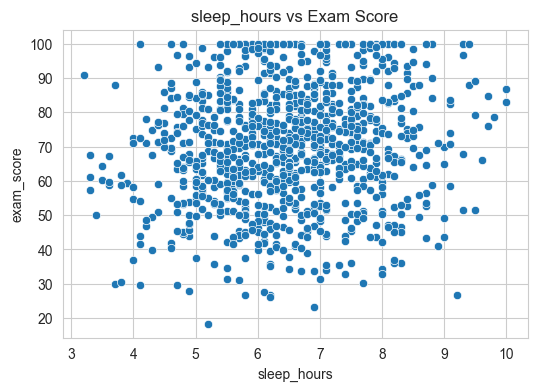

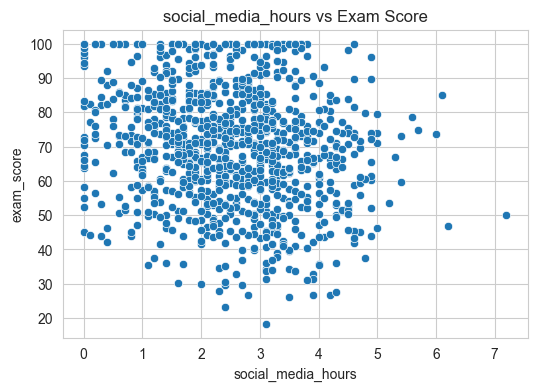

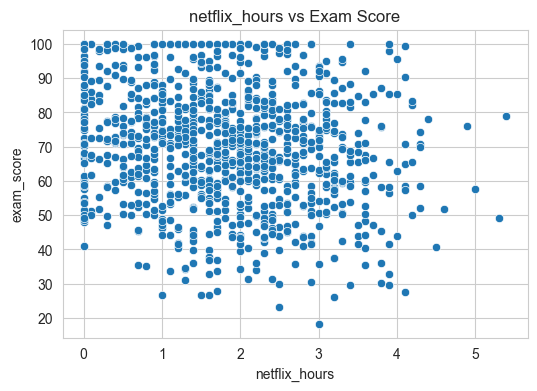

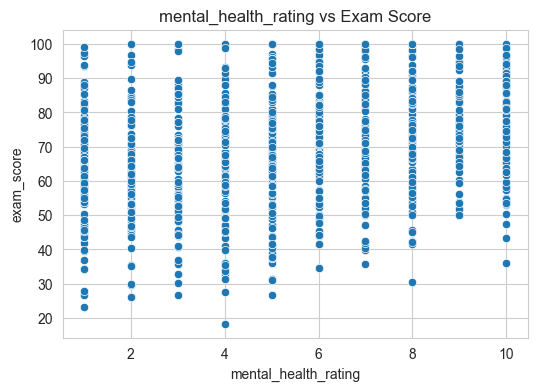

In [15]:
important_numeric_features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "mental_health_rating"
]

for col in important_numeric_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="exam_score")
    plt.title(f"{col} vs Exam Score")
    plt.show()


# **3.8 Boxplots for Categorical Features vs Exam Score**

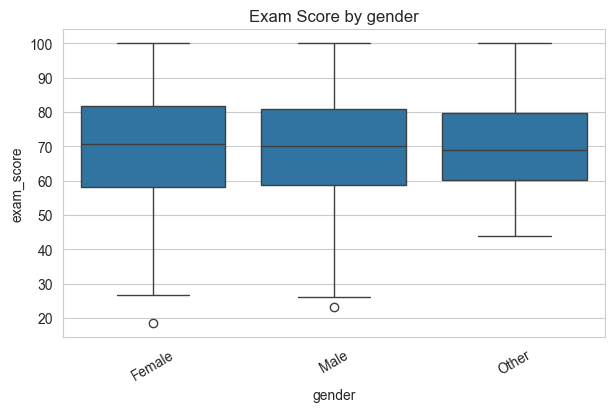

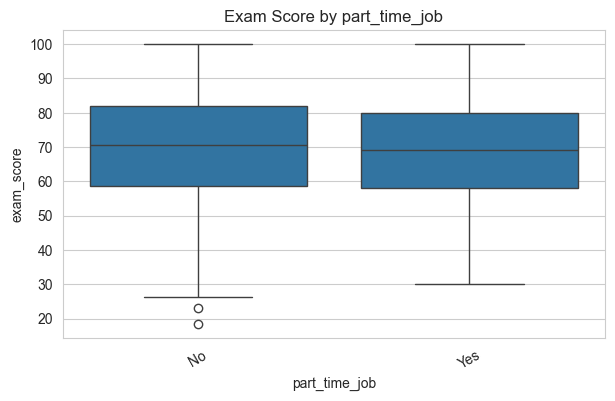

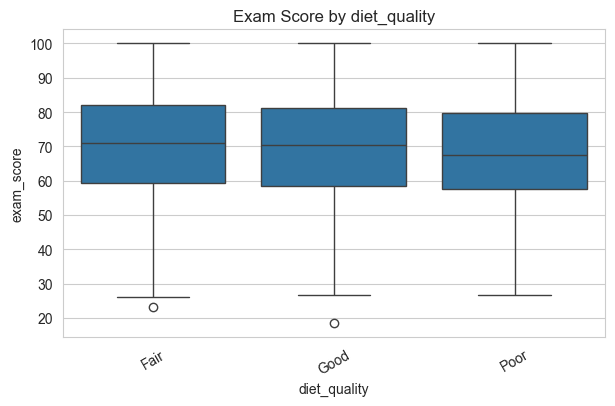

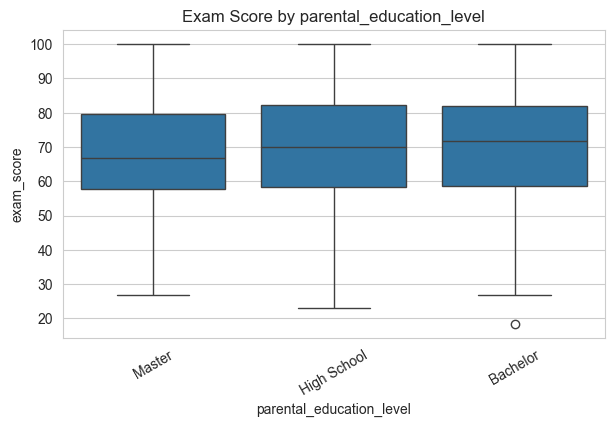

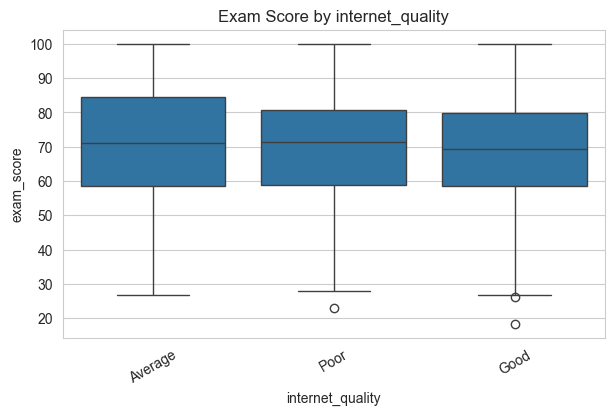

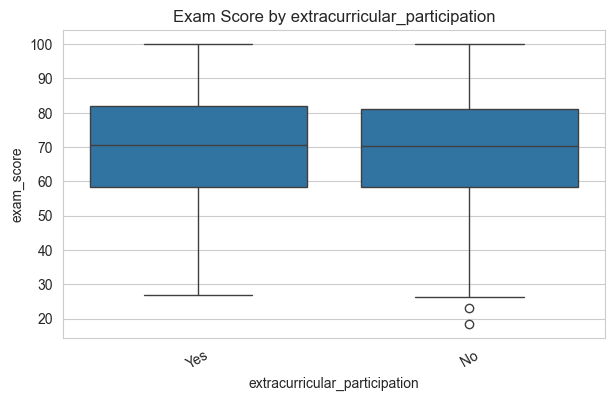

In [16]:
for col in categorical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=col, y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=30)
    plt.show()


# **3.9 Correlation Matrix**

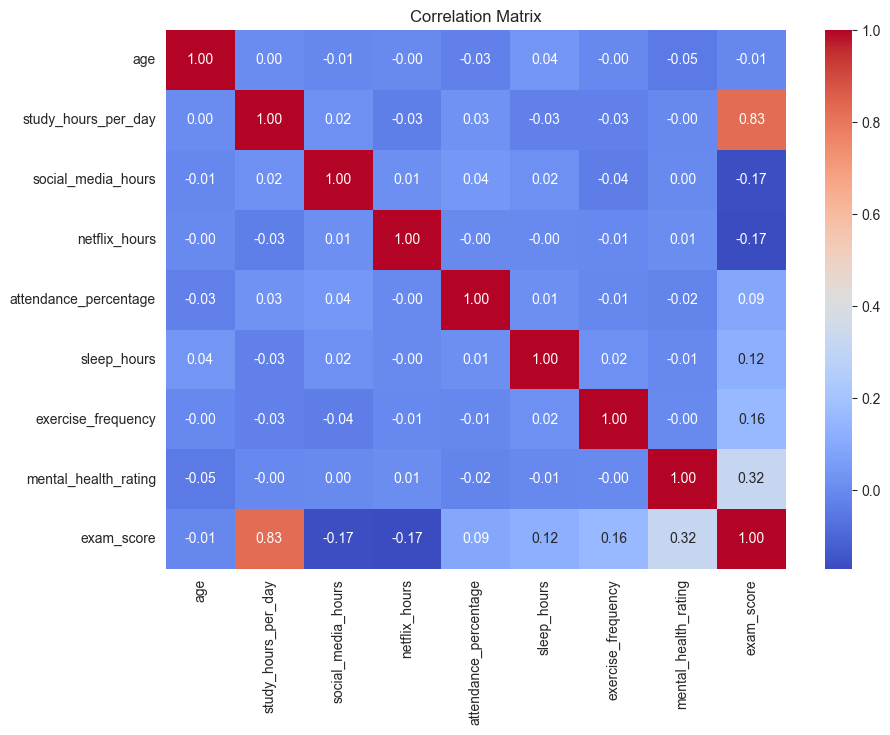

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_features_for_plot].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


# **3.10 Outlier Check Whit Boxplot**


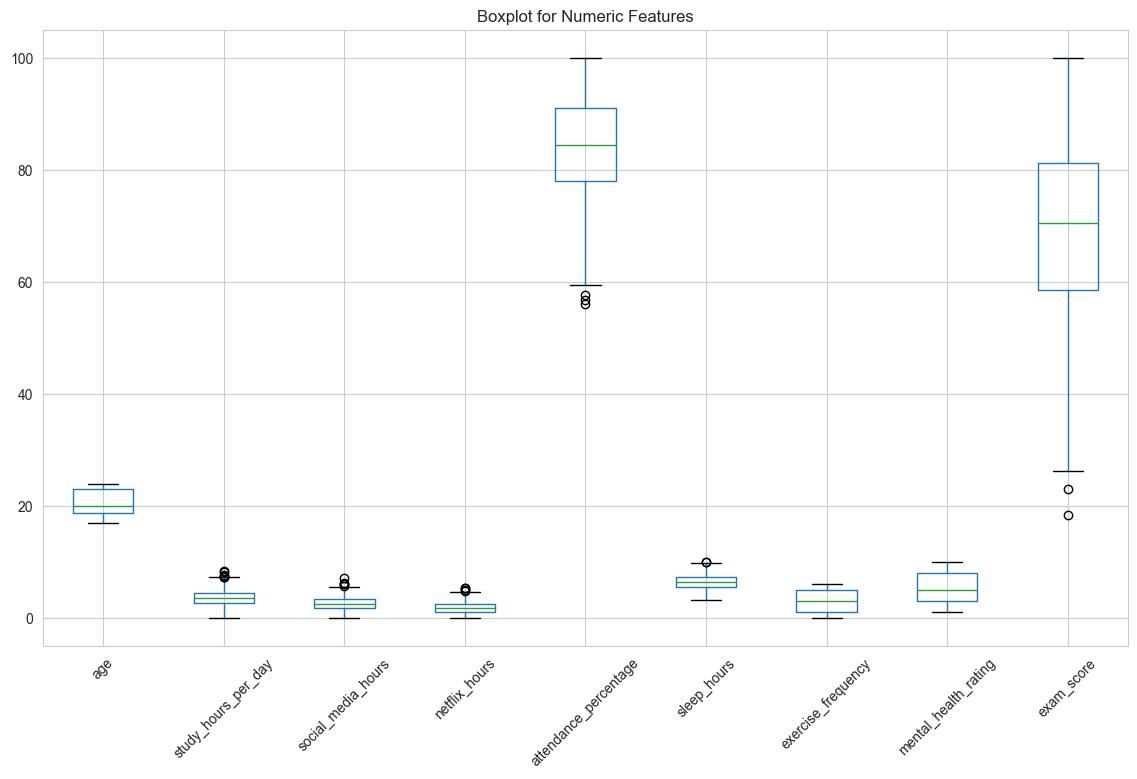

In [18]:
plt.figure(figsize=(14, 8))
df[numeric_features_for_plot].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot for Numeric Features")
plt.show()


# **4. Hypothesis Testing**

# **Helper Function**

In [19]:
def print_test_result(test_name, statistic, p_value, alpha=0.05):
    print(f"{test_name}")
    print(f"Statistic = {statistic:.4f}")
    print(f"P-value   = {p_value:.4f}")
    if p_value < alpha:
        print("Result    = Reject H0 (statistically significant)")
    else:
        print("Result    = Fail to reject H0 (not statistically significant)")
    print("-" * 60)



# **Hypothesis 1: Study Hours and Exam Score (Pearson)**

In [20]:
stat, p = pearsonr(df["study_hours_per_day"], df["exam_score"])
print_test_result("Pearson: study_hours_per_day vs exam_score", stat, p)



Pearson: study_hours_per_day vs exam_score
Statistic = 0.8254
P-value   = 0.0000
Result    = Reject H0 (statistically significant)
------------------------------------------------------------


# **Hypothesis 2: Part-time Job and Exam Score (t-test)**

In [21]:
group_yes = df[df["part_time_job"] == "Yes"]["exam_score"]
group_no = df[df["part_time_job"] == "No"]["exam_score"]

stat, p = ttest_ind(group_yes, group_no, equal_var=False)
print_test_result("T-test: part_time_job vs exam_score", stat, p)



T-test: part_time_job vs exam_score
Statistic = -0.8523
P-value   = 0.3946
Result    = Fail to reject H0 (not statistically significant)
------------------------------------------------------------


# **Hypothesis 3: High Attendance and Exam Score (t-test)**

In [22]:
attendance_median = df["attendance_percentage"].median()

high_attendance = df[df["attendance_percentage"] >= attendance_median]["exam_score"]
low_attendance = df[df["attendance_percentage"] < attendance_median]["exam_score"]

stat, p = ttest_ind(high_attendance, low_attendance, equal_var=False)
print_test_result("T-test: high attendance vs low attendance", stat, p)



T-test: high attendance vs low attendance
Statistic = 2.6865
P-value   = 0.0073
Result    = Reject H0 (statistically significant)
------------------------------------------------------------


# **Additional Hypothesis 4: Sleep Hours and Exam Score (Spearman)**

In [23]:
stat, p = spearmanr(df["sleep_hours"], df["exam_score"])
print_test_result("Spearman: sleep_hours vs exam_score", stat, p)



Spearman: sleep_hours vs exam_score
Statistic = 0.1234
P-value   = 0.0001
Result    = Reject H0 (statistically significant)
------------------------------------------------------------


# **Additional Hypothesis 5: Diet Quality and Exam Score (ANOVA)**

In [24]:
diet_groups = [group["exam_score"].values for _, group in df.groupby("diet_quality")]
stat, p = f_oneway(*diet_groups)
print_test_result("ANOVA: diet_quality vs exam_score", stat, p)



ANOVA: diet_quality vs exam_score
Statistic = 1.2662
P-value   = 0.2824
Result    = Fail to reject H0 (not statistically significant)
------------------------------------------------------------


# **Additional Hypothesis 6: Internet Quality and Exam Score (Kruskal-Wallis)**

In [25]:
internet_groups = [group["exam_score"].values for _, group in df.groupby("internet_quality")]
stat, p = kruskal(*internet_groups)
print_test_result("Kruskal-Wallis: internet_quality vs exam_score", stat, p)



Kruskal-Wallis: internet_quality vs exam_score
Statistic = 3.2213
P-value   = 0.1998
Result    = Fail to reject H0 (not statistically significant)
------------------------------------------------------------


# **Additional Hypothesis 7: Gender and Exam Score (ANOVA)**

In [26]:
from scipy.stats import f_oneway

gender_exam = df[['gender', 'exam_score']].dropna()

groups = [group['exam_score'].values for _, group in gender_exam.groupby('gender')]

f_stat, p_value = f_oneway(*groups)

print("Additional Hypothesis 7: Gender and Exam Score (ANOVA)")
print(f"Statistic = {f_stat:.4f}")
print(f"P-value   = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Result    = Reject H0 (statistically significant)")
else:
    print("Result    = Fail to reject H0 (not statistically significant)")



Additional Hypothesis 7: Gender and Exam Score (ANOVA)
Statistic = 0.1423
P-value   = 0.8674
Result    = Fail to reject H0 (not statistically significant)


# **Additional Hypothesis 8: Extracurricular Participation and High Exam Score (Chi-Square)**

In [27]:
df["high_exam_score"] = pd.cut(
    df["exam_score"],
    bins=[-np.inf, df["exam_score"].median(), np.inf],
    labels=["Low", "High"]
)

contingency_table = pd.crosstab(df["extracurricular_participation"], df["high_exam_score"])
stat, p, dof, expected = chi2_contingency(contingency_table)
print_test_result("Chi-Square: extracurricular_participation vs high_exam_score", stat, p)



Chi-Square: extracurricular_participation vs high_exam_score
Statistic = 0.0238
P-value   = 0.8774
Result    = Fail to reject H0 (not statistically significant)
------------------------------------------------------------


In [28]:
df = df.drop("high_exam_score", axis=1)


# **5. Preprocessing**

# **5.1 Remove Identifier and Define X, y**

In [29]:
df_model = df.copy()

# Remove student_id because it is an identifier
df_model = df_model.drop("student_id", axis=1)

X = df_model.drop("exam_score", axis=1)
y = df_model["exam_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (1000, 14)
y shape: (1000,)


# **5.2 Define Numeric and Categorical Columns**

In [30]:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)



Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
Numeric columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']


# **5.3 Train/Test Split**

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)



X_train shape: (800, 14)
X_test shape: (200, 14)


# **5.4 ColumnTransformer**

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)



# **5.5 Evaluation Function**

In [33]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse



In [34]:
def adjusted_r2_score(r2, n, p):
    if n - p - 1 == 0:
        return np.nan
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)


# **6. Baseline Regression Models**

# **6.1 Linear Regression**

In [35]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

linear_r2, linear_mae, linear_rmse = evaluate_model(y_test, linear_pred)
linear_cv = cross_val_score(linear_pipeline, X, y, cv=5, scoring="r2")

print("Linear Regression Results")
print("R2:", linear_r2)
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("CV R2 Mean:", linear_cv.mean())
print("CV R2 Std:", linear_cv.std())



Linear Regression Results
R2: 0.8967502640380203
MAE: 4.189311054627597
RMSE: 5.145506433284207
CV R2 Mean: 0.8955419909382136
CV R2 Std: 0.010553046962993324


# **6.2 Ridge Regression**

In [36]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)

ridge_r2, ridge_mae, ridge_rmse = evaluate_model(y_test, ridge_pred)
ridge_cv = cross_val_score(ridge_pipeline, X, y, cv=5, scoring="r2")

print("Ridge Regression Results")
print("Best Alpha:", ridge_pipeline.named_steps["model"].alpha_)
print("R2:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("CV R2 Mean:", ridge_cv.mean())
print("CV R2 Std:", ridge_cv.std())


Ridge Regression Results
Best Alpha: 10.0
R2: 0.896388883871767
MAE: 4.192304268892453
RMSE: 5.154503355737953
CV R2 Mean: 0.8957535542818823
CV R2 Std: 0.010110721634361445


# **6.3 Lasso Regression**

In [37]:
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LassoCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_test)

lasso_r2, lasso_mae, lasso_rmse = evaluate_model(y_test, lasso_pred)
lasso_cv = cross_val_score(lasso_pipeline, X, y, cv=5, scoring="r2")

print("Lasso Regression Results")
print("Best Alpha:", lasso_pipeline.named_steps["model"].alpha_)
print("R2:", lasso_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)
print("CV R2 Mean:", lasso_cv.mean())
print("CV R2 Std:", lasso_cv.std())


Lasso Regression Results
Best Alpha: 0.1
R2: 0.8981880829852785
MAE: 4.150618306623342
RMSE: 5.109553585403723
CV R2 Mean: 0.8970484508701745
CV R2 Std: 0.01041704579741758


# **6.4 Baseline Model Comparison Table**

In [38]:
baseline_simple_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2": [linear_r2, ridge_r2, lasso_r2],
    "MAE": [linear_mae, ridge_mae, lasso_mae],
    "RMSE": [linear_rmse, ridge_rmse, lasso_rmse],
    "CV R2 Mean": [linear_cv.mean(), ridge_cv.mean(), lasso_cv.mean()],
    "CV R2 Std": [linear_cv.std(), ridge_cv.std(), lasso_cv.std()]
})

baseline_simple_results


,Model,R2,MAE,RMSE,CV R2 Mean,CV R2 Std
0,Linear Regression,0.896750,4.189311,5.145506,0.895542,0.010553
1,Ridge Regression,0.896389,4.192304,5.154503,0.895754,0.010111
2,Lasso Regression,0.898188,4.150618,5.109554,0.897048,0.010417


# **7. Model Selection**

# **7.1 Prepare Data for Feature Selection**

In [39]:
# Fit preprocessor on full X for feature selection dataset
X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df.head()


,num__age,num__study_hours_per_day,num__social_media_hours,num__netflix_hours,num__attendance_percentage,num__sleep_hours,num__exercise_frequency,num__mental_health_rating,cat__gender_Male,cat__gender_Other,cat__part_time_job_Yes,cat__diet_quality_Good,cat__diet_quality_Poor,cat__parental_education_level_High School,cat__parental_education_level_Master,cat__parental_education_level_nan,cat__internet_quality_Good,cat__internet_quality_Poor,cat__extracurricular_participation_Yes
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


# **7.2 Helper Functions**

In [40]:
def evaluate_subset_cv(X_subset, y, cv=5):
    model = LinearRegression()
    scores = cross_val_score(model, X_subset, y, cv=cv, scoring="r2")
    return scores.mean()



In [41]:
def evaluate_selected_features(X_full_df, selected_features, y, test_size=0.2, random_state=42):
    X_selected = X_full_df[selected_features]
    
    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
        X_selected, y, test_size=test_size, random_state=random_state
    )
    
    model = LinearRegression()
    model.fit(X_train_fs, y_train_fs)
    y_pred_fs = model.predict(X_test_fs)
    
    r2 = r2_score(y_test_fs, y_pred_fs)
    mae = mean_absolute_error(y_test_fs, y_pred_fs)
    rmse = np.sqrt(mean_squared_error(y_test_fs, y_pred_fs))
    adj_r2 = adjusted_r2_score(r2, len(y_test_fs), X_selected.shape[1])
    cv_r2 = evaluate_subset_cv(X_selected, y, cv=5)
    
    return {
        "R2": r2,
        "Adjusted R2": adj_r2,
        "MAE": mae,
        "RMSE": rmse,
        "CV R2": cv_r2,
        "Num Features": len(selected_features),
        "Selected Features": selected_features
    }


# **7.3 Forward Selection**

In [42]:
remaining_features = list(X_processed_df.columns)
selected_forward = []
best_score = -np.inf

forward_history = []

while len(remaining_features) > 0:
    scores = []
    
    for feature in remaining_features:
        trial_features = selected_forward + [feature]
        score = evaluate_subset_cv(X_processed_df[trial_features], y)
        scores.append((feature, score))
    
    best_feature, current_score = max(scores, key=lambda x: x[1])
    
    if current_score > best_score:
        selected_forward.append(best_feature)
        remaining_features.remove(best_feature)
        best_score = current_score
        forward_history.append((len(selected_forward), best_feature, best_score))
    else:
        break

forward_results = evaluate_selected_features(X_processed_df, selected_forward, y)

print("Forward Selection Features:")
print(selected_forward)
print("\nForward Selection Results:")
print(forward_results)



Forward Selection Features:
['num__study_hours_per_day', 'num__mental_health_rating', 'num__social_media_hours', 'num__exercise_frequency', 'num__sleep_hours', 'num__netflix_hours', 'num__attendance_percentage', 'cat__diet_quality_Good', 'cat__internet_quality_Good']

Forward Selection Results:
{'R2': 0.8991509228493196, 'Adjusted R2': 0.8943738613000769, 'MAE': 4.127265868300255, 'RMSE': np.float64(5.085335552958449), 'CV R2': np.float64(0.8975517723167045), 'Num Features': 9, 'Selected Features': ['num__study_hours_per_day', 'num__mental_health_rating', 'num__social_media_hours', 'num__exercise_frequency', 'num__sleep_hours', 'num__netflix_hours', 'num__attendance_percentage', 'cat__diet_quality_Good', 'cat__internet_quality_Good']}


# **7.4 Backward Elimination**

In [43]:
selected_backward = list(X_processed_df.columns)
best_backward_score = evaluate_subset_cv(X_processed_df[selected_backward], y)

backward_history = []

improved = True
while improved and len(selected_backward) > 1:
    improved = False
    scores = []
    
    for feature in selected_backward:
        trial_features = [f for f in selected_backward if f != feature]
        score = evaluate_subset_cv(X_processed_df[trial_features], y)
        scores.append((feature, score, trial_features))
    
    feature_to_remove, current_score, best_trial_features = max(scores, key=lambda x: x[1])
    
    if current_score > best_backward_score:
        selected_backward = best_trial_features
        best_backward_score = current_score
        backward_history.append((len(selected_backward), feature_to_remove, best_backward_score))
        improved = True

backward_results = evaluate_selected_features(X_processed_df, selected_backward, y)

print("Backward Elimination Features:")
print(selected_backward)
print("\nBackward Elimination Results:")
print(backward_results)



Backward Elimination Features:
['num__study_hours_per_day', 'num__social_media_hours', 'num__netflix_hours', 'num__attendance_percentage', 'num__sleep_hours', 'num__exercise_frequency', 'num__mental_health_rating', 'cat__diet_quality_Good', 'cat__internet_quality_Good']

Backward Elimination Results:
{'R2': 0.8991509228493195, 'Adjusted R2': 0.8943738613000768, 'MAE': 4.127265868300257, 'RMSE': np.float64(5.085335552958451), 'CV R2': np.float64(0.8975517723167045), 'Num Features': 9, 'Selected Features': ['num__study_hours_per_day', 'num__social_media_hours', 'num__netflix_hours', 'num__attendance_percentage', 'num__sleep_hours', 'num__exercise_frequency', 'num__mental_health_rating', 'cat__diet_quality_Good', 'cat__internet_quality_Good']}


# **7.5 Hybrid Selection**

In [44]:
remaining_features = list(X_processed_df.columns)
selected_hybrid = []
best_hybrid_score = -np.inf

hybrid_history = []

improved = True
while improved and len(remaining_features) > 0:
    improved = False
    
    # Forward step
    scores = []
    for feature in remaining_features:
        trial_features = selected_hybrid + [feature]
        score = evaluate_subset_cv(X_processed_df[trial_features], y)
        scores.append((feature, score))
    
    best_feature, current_score = max(scores, key=lambda x: x[1])
    
    if current_score > best_hybrid_score:
        selected_hybrid.append(best_feature)
        remaining_features.remove(best_feature)
        best_hybrid_score = current_score
        hybrid_history.append(("add", best_feature, best_hybrid_score))
        improved = True
    
    # Backward step
    if len(selected_hybrid) > 1:
        scores = []
        for feature in selected_hybrid:
            trial_features = [f for f in selected_hybrid if f != feature]
            score = evaluate_subset_cv(X_processed_df[trial_features], y)
            scores.append((feature, score, trial_features))
        
        feature_to_remove, remove_score, best_trial_features = max(scores, key=lambda x: x[1])
        
        if remove_score > best_hybrid_score:
            selected_hybrid = best_trial_features
            remaining_features.append(feature_to_remove)
            best_hybrid_score = remove_score
            hybrid_history.append(("remove", feature_to_remove, best_hybrid_score))
            improved = True

hybrid_results = evaluate_selected_features(X_processed_df, selected_hybrid, y)

print("Hybrid Selection Features:")
print(selected_hybrid)
print("\nHybrid Selection Results:")
print(hybrid_results)



Hybrid Selection Features:
['num__study_hours_per_day', 'num__mental_health_rating', 'num__social_media_hours', 'num__exercise_frequency', 'num__sleep_hours', 'num__netflix_hours', 'num__attendance_percentage', 'cat__diet_quality_Good', 'cat__internet_quality_Good']

Hybrid Selection Results:
{'R2': 0.8991509228493196, 'Adjusted R2': 0.8943738613000769, 'MAE': 4.127265868300255, 'RMSE': np.float64(5.085335552958449), 'CV R2': np.float64(0.8975517723167045), 'Num Features': 9, 'Selected Features': ['num__study_hours_per_day', 'num__mental_health_rating', 'num__social_media_hours', 'num__exercise_frequency', 'num__sleep_hours', 'num__netflix_hours', 'num__attendance_percentage', 'cat__diet_quality_Good', 'cat__internet_quality_Good']}


# **7.6 Best Subset Selection**

In [45]:
# To keep computation reasonable, use a reduced candidate feature set
candidate_features = [
    "num__study_hours_per_day",
    "num__attendance_percentage",
    "num__sleep_hours",
    "num__social_media_hours",
    "num__netflix_hours",
    "num__mental_health_rating",
    "num__exercise_frequency",
    "num__age"
]

best_subset_score = -np.inf
best_subset_features = None

for k in range(1, len(candidate_features) + 1):
    for subset in itertools.combinations(candidate_features, k):
        subset = list(subset)
        score = evaluate_subset_cv(X_processed_df[subset], y)
        
        if score > best_subset_score:
            best_subset_score = score
            best_subset_features = subset

best_subset_results = evaluate_selected_features(X_processed_df, best_subset_features, y)

print("Best Subset Features:")
print(best_subset_features)
print("\nBest Subset Results:")
print(best_subset_results)



Best Subset Features:
['num__study_hours_per_day', 'num__attendance_percentage', 'num__sleep_hours', 'num__social_media_hours', 'num__netflix_hours', 'num__mental_health_rating', 'num__exercise_frequency']

Best Subset Results:
{'R2': 0.8995801560882966, 'Adjusted R2': 0.8959190159456824, 'MAE': 4.113913694442796, 'RMSE': np.float64(5.074501925779437), 'CV R2': np.float64(0.8974820575001408), 'Num Features': 7, 'Selected Features': ['num__study_hours_per_day', 'num__attendance_percentage', 'num__sleep_hours', 'num__social_media_hours', 'num__netflix_hours', 'num__mental_health_rating', 'num__exercise_frequency']}


# **7.7 Selection Results Table**

In [46]:
selection_results = pd.DataFrame([
    {
        "Method": "Forward Selection",
        **forward_results
    },
    {
        "Method": "Backward Elimination",
        **backward_results
    },
    {
        "Method": "Hybrid Selection",
        **hybrid_results
    },
    {
        "Method": "Best Subset Selection",
        **best_subset_results
    }
])

selection_results



,Method,R2,Adjusted R2,MAE,RMSE,CV R2,Num Features,Selected Features
0,Forward Selection,0.899151,0.894374,4.127266,5.085336,0.897552,9,"[num__study_hours_per_day, num__mental_health_..."
1,Backward Elimination,0.899151,0.894374,4.127266,5.085336,0.897552,9,"[num__study_hours_per_day, num__social_media_h..."
2,Hybrid Selection,0.899151,0.894374,4.127266,5.085336,0.897552,9,"[num__study_hours_per_day, num__mental_health_..."
3,Best Subset Selection,0.899580,0.895919,4.113914,5.074502,0.897482,7,"[num__study_hours_per_day, num__attendance_per..."


# **7.8 Visual Comparison of Selection Methods**

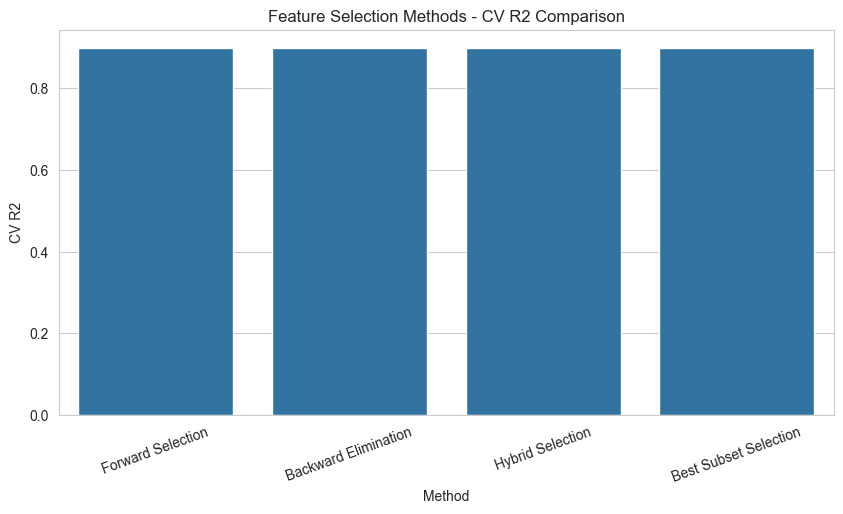

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(data=selection_results, x="Method", y="CV R2")
plt.title("Feature Selection Methods - CV R2 Comparison")
plt.xticks(rotation=20)
plt.show()      

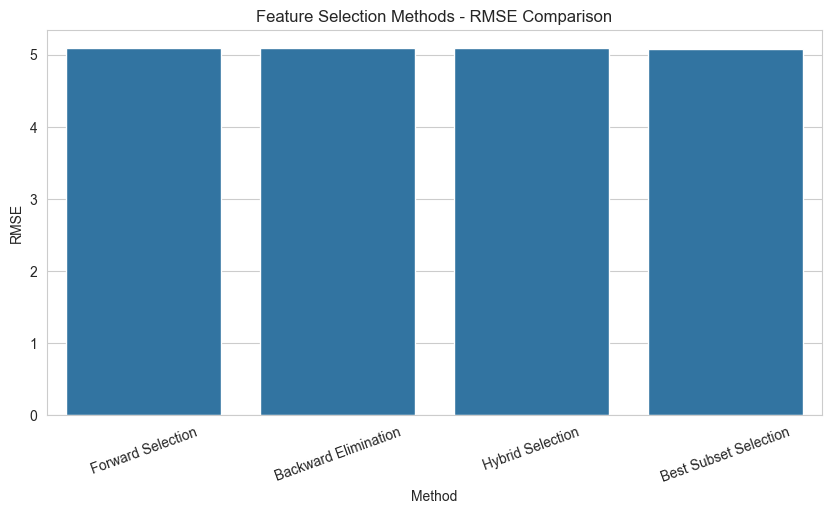

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(data=selection_results, x="Method", y="RMSE")
plt.title("Feature Selection Methods - RMSE Comparison")
plt.xticks(rotation=20)
plt.show()


# **8. Final Comparison**

# **8.1 Helper Function for Baseline Evaluation**

In [49]:
def evaluate_pipeline_model(model_name, pipeline, X, y, test_size=0.2, random_state=42):
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    pipeline.fit(X_train_temp, y_train_temp)
    y_pred_temp = pipeline.predict(X_test_temp)
    
    r2 = r2_score(y_test_temp, y_pred_temp)
    mae = mean_absolute_error(y_test_temp, y_pred_temp)
    rmse = np.sqrt(mean_squared_error(y_test_temp, y_pred_temp))
    
    n = len(y_test_temp)
    p = X_test_temp.shape[1]
    adj_r2 = adjusted_r2_score(r2, n, p)
    
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
    
    return {
        "Approach": model_name,
        "Category": "Baseline Model",
        "R2": r2,
        "Adjusted R2": adj_r2,
        "MAE": mae,
        "RMSE": rmse,
        "CV R2": cv_scores.mean(),
        "CV R2 Std": cv_scores.std(),
        "Num Features": X.shape[1]
    }



# **8.2 Baseline Results Table**

In [50]:
baseline_results = pd.DataFrame([
    evaluate_pipeline_model("Linear Regression", linear_pipeline, X, y),
    evaluate_pipeline_model("Ridge Regression", ridge_pipeline, X, y),
    evaluate_pipeline_model("Lasso Regression", lasso_pipeline, X, y)
])

baseline_results



,Approach,Category,R2,Adjusted R2,MAE,RMSE,CV R2,CV R2 Std,Num Features
0,Linear Regression,Baseline Model,0.896750,0.888937,4.189311,5.145506,0.895542,0.010553,14
1,Ridge Regression,Baseline Model,0.896389,0.888548,4.192304,5.154503,0.895754,0.010111,14
2,Lasso Regression,Baseline Model,0.898188,0.890483,4.150618,5.109554,0.897048,0.010417,14


# **8.3 Prepare Feature Selection Results**

In [51]:
feature_selection_results = selection_results.copy()

feature_selection_results = feature_selection_results.rename(columns={"Method": "Approach"})
feature_selection_results["Category"] = "Feature Selection"
feature_selection_results["CV R2 Std"] = np.nan

feature_selection_results = feature_selection_results[
    ["Approach", "Category", "R2", "Adjusted R2", "MAE", "RMSE", "CV R2", "CV R2 Std", "Num Features"]
]

feature_selection_results



,Approach,Category,R2,Adjusted R2,MAE,RMSE,CV R2,CV R2 Std,Num Features
0,Forward Selection,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
1,Backward Elimination,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
2,Hybrid Selection,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
3,Best Subset Selection,Feature Selection,0.899580,0.895919,4.113914,5.074502,0.897482,NaN,7


# **8.4 Combine All Results**

In [52]:
final_comparison = pd.concat(
    [baseline_results, feature_selection_results],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(by="RMSE", ascending=True)
final_comparison



,Approach,Category,R2,Adjusted R2,MAE,RMSE,CV R2,CV R2 Std,Num Features
6,Best Subset Selection,Feature Selection,0.899580,0.895919,4.113914,5.074502,0.897482,NaN,7
3,Forward Selection,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
5,Hybrid Selection,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
4,Backward Elimination,Feature Selection,0.899151,0.894374,4.127266,5.085336,0.897552,NaN,9
2,Lasso Regression,Baseline Model,0.898188,0.890483,4.150618,5.109554,0.897048,0.010417,14
0,Linear Regression,Baseline Model,0.896750,0.888937,4.189311,5.145506,0.895542,0.010553,14
1,Ridge Regression,Baseline Model,0.896389,0.888548,4.192304,5.154503,0.895754,0.010111,14


# **8.5 Best Overall Approach**

In [53]:
best_overall = final_comparison.iloc[0]

print("Best Overall Approach")
print("Approach:", best_overall["Approach"])
print("Category:", best_overall["Category"])
print("R2:", best_overall["R2"])
print("Adjusted R2:", best_overall["Adjusted R2"])
print("MAE:", best_overall["MAE"])
print("RMSE:", best_overall["RMSE"])
print("CV R2:", best_overall["CV R2"])
print("Number of Features:", best_overall["Num Features"])



Best Overall Approach
Approach: Best Subset Selection
Category: Feature Selection
R2: 0.8995801560882966
Adjusted R2: 0.8959190159456824
MAE: 4.113913694442796
RMSE: 5.074501925779437
CV R2: 0.8974820575001408
Number of Features: 7


# **8.6 Best Baseline and Best Feature Selection**

In [54]:
best_baseline = baseline_results.sort_values(by="RMSE", ascending=True).iloc[0]
best_feature_selection = feature_selection_results.sort_values(by="RMSE", ascending=True).iloc[0]

print("Best Baseline Model:", best_baseline["Approach"])
print("Best Feature Selection Method:", best_feature_selection["Approach"])



Best Baseline Model: Lasso Regression
Best Feature Selection Method: Best Subset Selection


# **8.7 Visual Comparison**

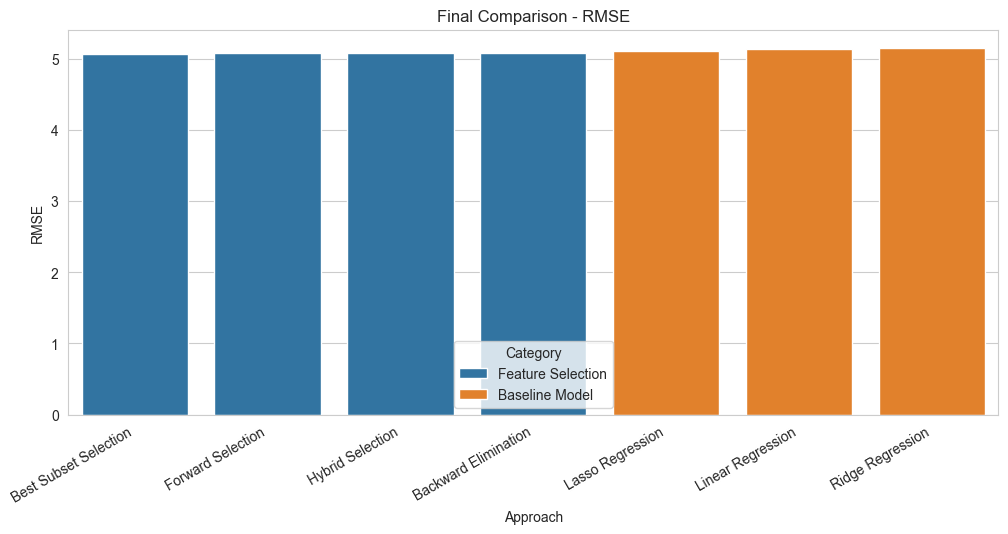

In [55]:
plt.figure(figsize=(12, 5))
sns.barplot(data=final_comparison, x="Approach", y="RMSE", hue="Category")
plt.title("Final Comparison - RMSE")
plt.xticks(rotation=30, ha="right")
plt.show()



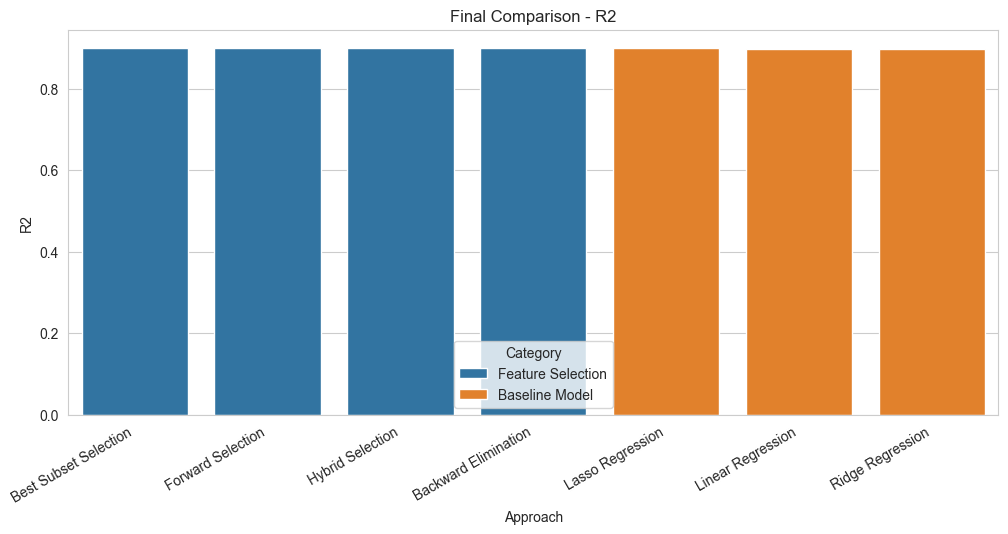

In [56]:
plt.figure(figsize=(12, 5))
sns.barplot(data=final_comparison, x="Approach", y="R2", hue="Category")
plt.title("Final Comparison - R2")
plt.xticks(rotation=30, ha="right")
plt.show()


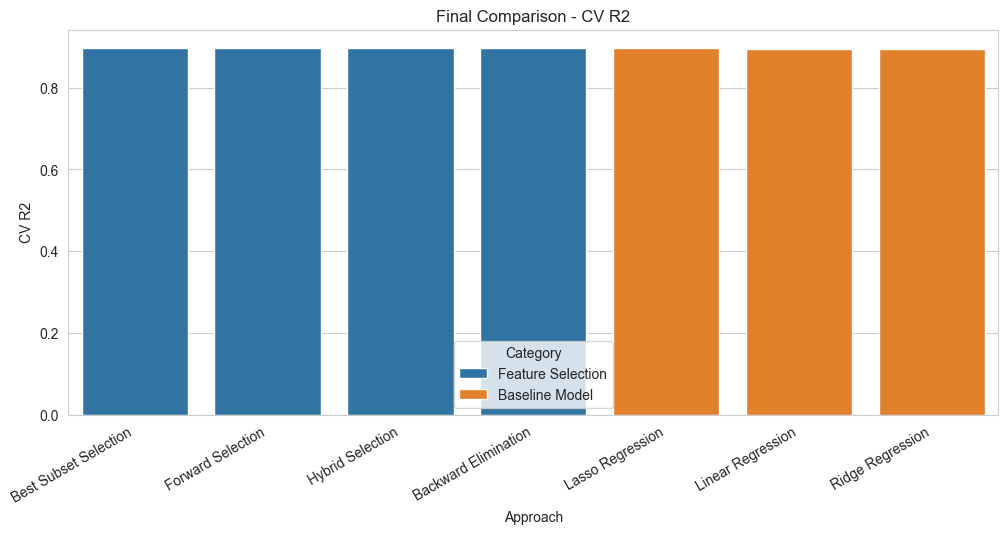

In [57]:
plt.figure(figsize=(12, 5))
sns.barplot(data=final_comparison, x="Approach", y="CV R2", hue="Category")
plt.title("Final Comparison - CV R2")
plt.xticks(rotation=30, ha="right")
plt.show()


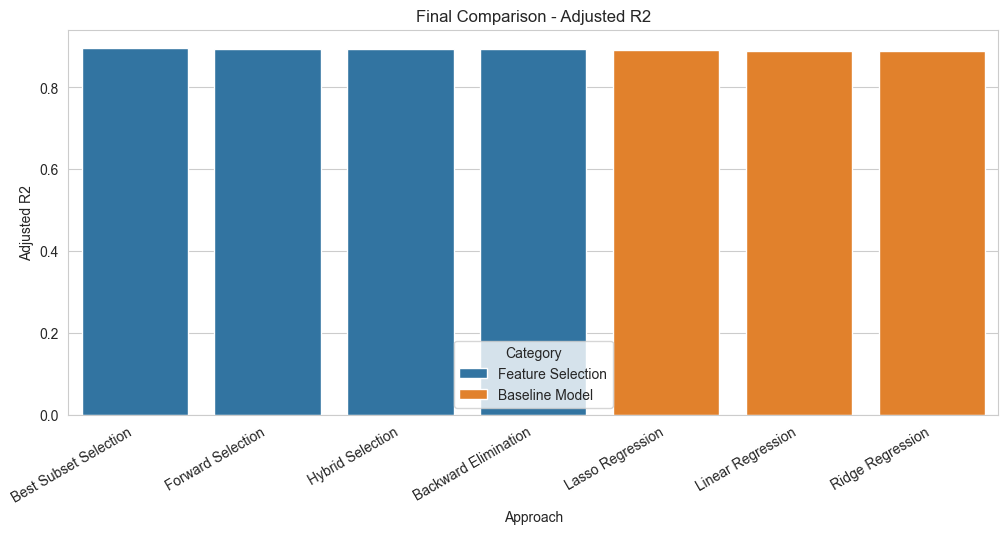

In [58]:
plt.figure(figsize=(12, 5))
sns.barplot(data=final_comparison, x="Approach", y="Adjusted R2", hue="Category")
plt.title("Final Comparison - Adjusted R2")
plt.xticks(rotation=30, ha="right")
plt.show()


# **9. Feature Importance**

# **9.1 Helper Function**

In [59]:
def get_feature_importance(trained_pipeline, model_name):
    feature_names = trained_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefficients = trained_pipeline.named_steps["model"].coef_
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })
    
    importance_df["Importance"] = importance_df["Coefficient"].abs()
    importance_df = importance_df.sort_values(by="Importance", ascending=False)
    
    print(f"\nTop Features for {model_name}")
    display(importance_df.head(15))
    
    return importance_df


# **9.2 Linear Regression Importance**

In [60]:
linear_importance = get_feature_importance(linear_pipeline, "Linear Regression")



Top Features for Linear Regression


,Feature,Coefficient,Importance
1,num__study_hours_per_day,14.144736,14.144736
7,num__mental_health_rating,5.564302,5.564302
2,num__social_media_hours,-3.133815,3.133815
6,num__exercise_frequency,2.656236,2.656236
3,num__netflix_hours,-2.534400,2.534400
5,num__sleep_hours,2.421586,2.421586
4,num__attendance_percentage,1.359685,1.359685
11,cat__diet_quality_Good,-0.958356,0.958356
15,cat__parental_education_level_nan,-0.839483,0.839483
9,cat__gender_Other,0.810709,0.810709


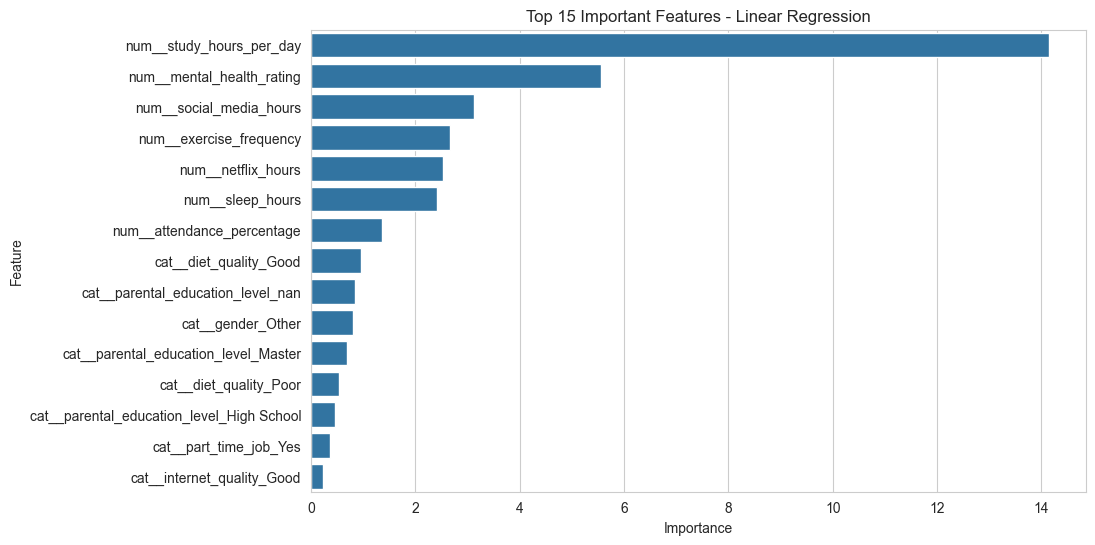

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(data=linear_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features - Linear Regression")
plt.show()


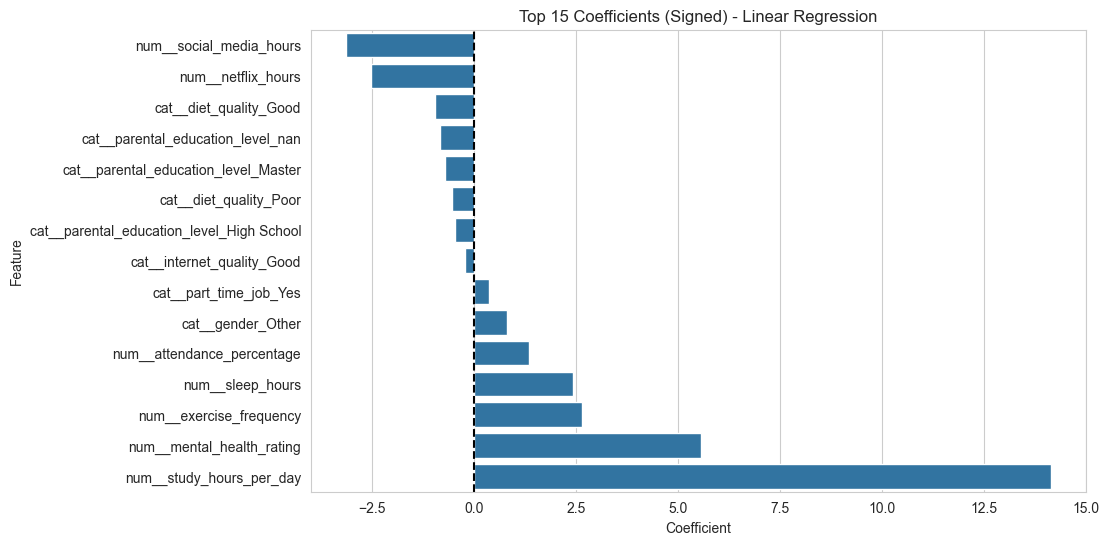

In [62]:
plt.figure(figsize=(10, 6))
top_linear_signed = linear_importance.head(15).sort_values(by="Coefficient")
sns.barplot(data=top_linear_signed, x="Coefficient", y="Feature")
plt.axvline(0, color="black", linestyle="--")
plt.title("Top 15 Coefficients (Signed) - Linear Regression")
plt.show()


# **9.3 Ridge Regression Importance**

In [63]:
ridge_importance = get_feature_importance(ridge_pipeline, "Ridge Regression")



Top Features for Ridge Regression


,Feature,Coefficient,Importance
1,num__study_hours_per_day,13.968738,13.968738
7,num__mental_health_rating,5.496756,5.496756
2,num__social_media_hours,-3.098816,3.098816
6,num__exercise_frequency,2.620804,2.620804
3,num__netflix_hours,-2.505297,2.505297
5,num__sleep_hours,2.391551,2.391551
4,num__attendance_percentage,1.345267,1.345267
11,cat__diet_quality_Good,-0.896721,0.896721
15,cat__parental_education_level_nan,-0.675470,0.675470
14,cat__parental_education_level_Master,-0.611744,0.611744


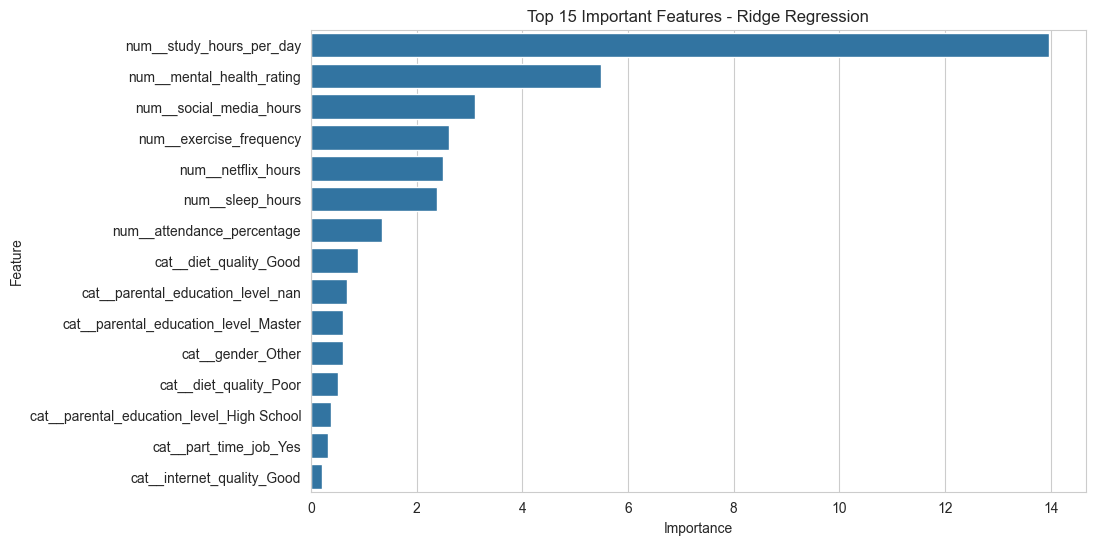

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ridge_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features - Ridge Regression")
plt.show()


# **9.4 Lasso Regression Importance**

In [65]:
lasso_importance = get_feature_importance(lasso_pipeline, "Lasso Regression")



Top Features for Lasso Regression


,Feature,Coefficient,Importance
1,num__study_hours_per_day,14.050209,14.050209
7,num__mental_health_rating,5.463696,5.463696
2,num__social_media_hours,-3.055746,3.055746
6,num__exercise_frequency,2.553003,2.553003
3,num__netflix_hours,-2.436744,2.436744
5,num__sleep_hours,2.339316,2.339316
4,num__attendance_percentage,1.262804,1.262804
11,cat__diet_quality_Good,-0.381695,0.381695
0,num__age,0.019849,0.019849
9,cat__gender_Other,0.000000,0.000000


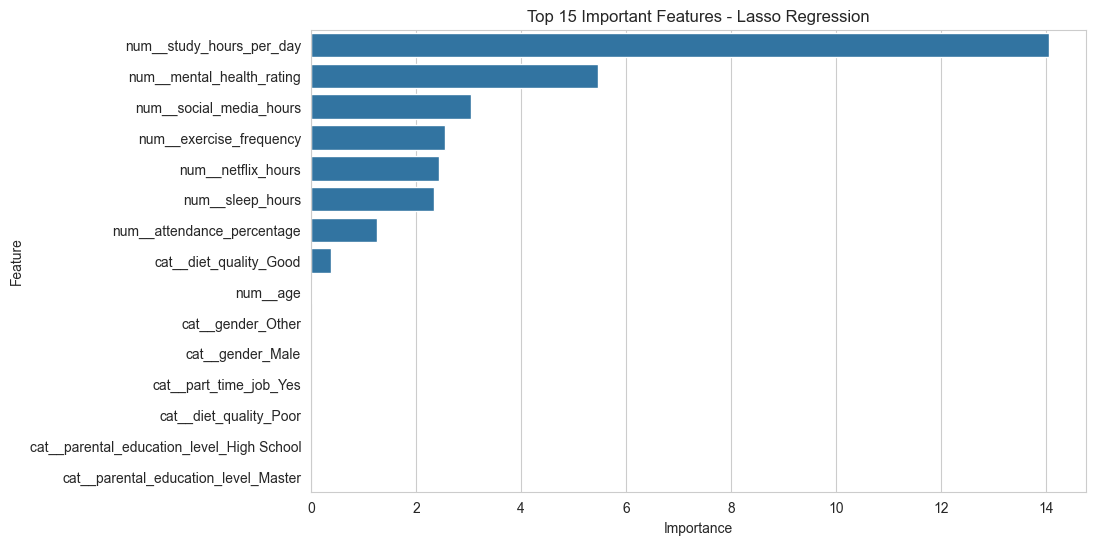

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(data=lasso_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features - Lasso Regression")
plt.show()


# **9.5 Features Removed by Lasso**

In [67]:
lasso_zero_features = lasso_importance[lasso_importance["Coefficient"] == 0]

print("Features with zero coefficient in Lasso:")
lasso_zero_features


Features with zero coefficient in Lasso:


,Feature,Coefficient,Importance
9,cat__gender_Other,0.0,0.0
8,cat__gender_Male,0.0,0.0
10,cat__part_time_job_Yes,0.0,0.0
12,cat__diet_quality_Poor,-0.0,0.0
13,cat__parental_education_level_High School,-0.0,0.0
14,cat__parental_education_level_Master,-0.0,0.0
15,cat__parental_education_level_nan,-0.0,0.0
16,cat__internet_quality_Good,-0.0,0.0
17,cat__internet_quality_Poor,0.0,0.0
18,cat__extracurricular_participation_Yes,-0.0,0.0


# **9.6 Compare Importance Across Models**

In [68]:
comparison_importance = linear_importance[["Feature", "Importance"]].rename(columns={"Importance": "Linear"})
comparison_importance = comparison_importance.merge(
    ridge_importance[["Feature", "Importance"]].rename(columns={"Importance": "Ridge"}),
    on="Feature",
    how="outer"
)
comparison_importance = comparison_importance.merge(
    lasso_importance[["Feature", "Importance"]].rename(columns={"Importance": "Lasso"}),
    on="Feature",
    how="outer"
)

comparison_importance = comparison_importance.fillna(0)
comparison_importance["Average Importance"] = comparison_importance[["Linear", "Ridge", "Lasso"]].mean(axis=1)
comparison_importance = comparison_importance.sort_values(by="Average Importance", ascending=False)

comparison_importance.head(15)


,Feature,Linear,Ridge,Lasso,Average Importance
18,num__study_hours_per_day,14.144736,13.968738,14.050209,14.054561
14,num__mental_health_rating,5.564302,5.496756,5.463696,5.508251
17,num__social_media_hours,3.133815,3.098816,3.055746,3.096126
13,num__exercise_frequency,2.656236,2.620804,2.553003,2.610014
15,num__netflix_hours,2.534400,2.505297,2.436744,2.492147
16,num__sleep_hours,2.421586,2.391551,2.339316,2.384151
12,num__attendance_percentage,1.359685,1.345267,1.262804,1.322585
0,cat__diet_quality_Good,0.958356,0.896721,0.381695,0.745591
9,cat__parental_education_level_nan,0.839483,0.675470,0.000000,0.504984
4,cat__gender_Other,0.810709,0.601269,0.000000,0.470659


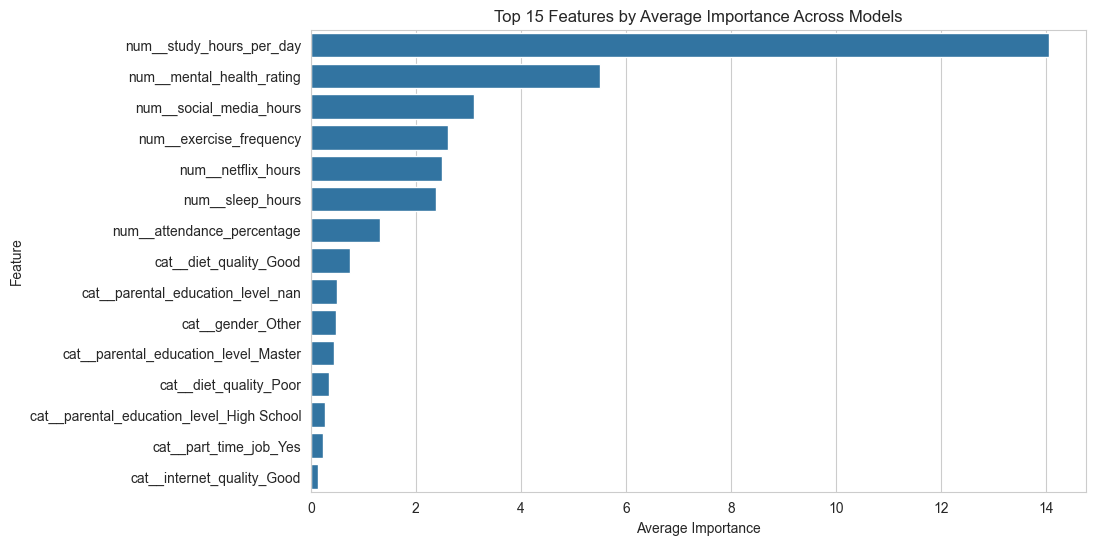

In [69]:
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_importance.head(15), x="Average Importance", y="Feature")
plt.title("Top 15 Features by Average Importance Across Models")
plt.show()


# **10. Bias-Variance / Learning Curve**

# **10.1 Learning Curve Function**

In [70]:
def plot_learning_curve(model, model_name, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, test_mean, marker="o", label="Validation Score")
    
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)
    
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.show()


# **10.2 Plot Learning Curves**

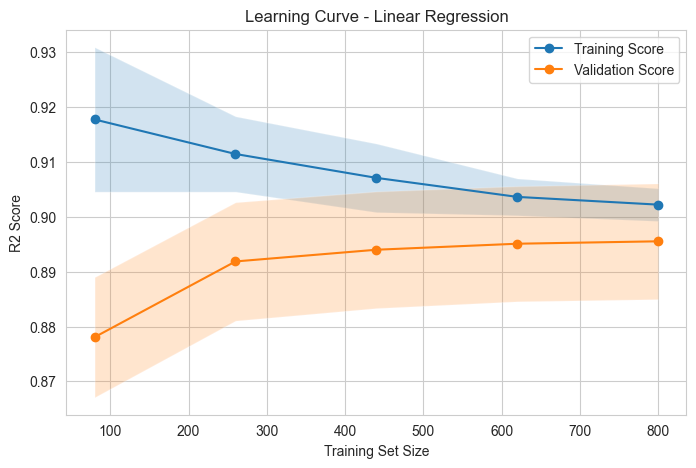

In [71]:
plot_learning_curve(linear_pipeline, "Linear Regression", X, y)


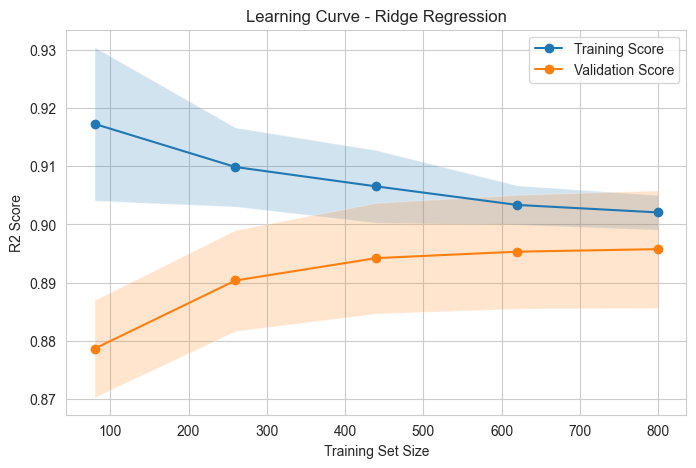

In [72]:
plot_learning_curve(ridge_pipeline, "Ridge Regression", X, y)


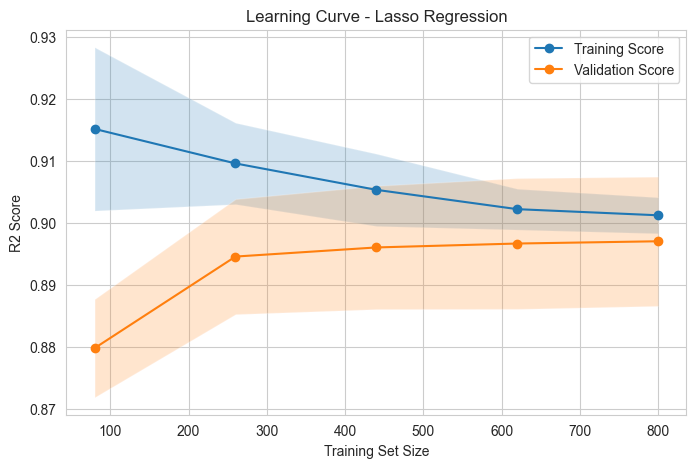

In [73]:
plot_learning_curve(lasso_pipeline, "Lasso Regression", X, y)


# **10.3 Simple Bias-Variance Interpretation**

In [74]:
def interpret_bias_variance(model_name, train_score, val_score):
    gap = train_score - val_score
    
    print(f"Model: {model_name}")
    print(f"Train Score: {train_score:.4f}")
    print(f"Validation Score: {val_score:.4f}")
    print(f"Gap: {gap:.4f}")
    
    if train_score < 0.5 and val_score < 0.5:
        print("Interpretation: High bias (underfitting)")
    elif gap > 0.1:
        print("Interpretation: High variance (overfitting)")
    else:
        print("Interpretation: Balanced bias-variance tradeoff")
    
    print("-" * 50)


In [75]:
# Approximate interpretation using CV means
interpret_bias_variance("Linear Regression", linear_r2, linear_cv.mean())
interpret_bias_variance("Ridge Regression", ridge_r2, ridge_cv.mean())
interpret_bias_variance("Lasso Regression", lasso_r2, lasso_cv.mean())


Model: Linear Regression
Train Score: 0.8968
Validation Score: 0.8955
Gap: 0.0012
Interpretation: Balanced bias-variance tradeoff
--------------------------------------------------
Model: Ridge Regression
Train Score: 0.8964
Validation Score: 0.8958
Gap: 0.0006
Interpretation: Balanced bias-variance tradeoff
--------------------------------------------------
Model: Lasso Regression
Train Score: 0.8982
Validation Score: 0.8970
Gap: 0.0011
Interpretation: Balanced bias-variance tradeoff
--------------------------------------------------


# **Leakage**
A Pipeline was used to combine preprocessing and modeling steps. The ColumnTransformer
standardizes numeric features and one-hot encodes categorical features. Since the
preprocessing steps are inside the Pipeline, they are fitted only on the training data
during train/test splitting and only on the training folds during cross-validation.
This prevents data leakage and ensures that information from the test set is not used
during training.


# **11. Conclusion**

# **11.1 Final Best Model Summary**

In [76]:
print("Final Best Overall Approach")
print("-" * 40)
print("Approach:", best_overall["Approach"])
print("Category:", best_overall["Category"])
print("R2:", round(best_overall["R2"], 4))
print("Adjusted R2:", round(best_overall["Adjusted R2"], 4))
print("MAE:", round(best_overall["MAE"], 4))
print("RMSE:", round(best_overall["RMSE"], 4))
print("CV R2:", round(best_overall["CV R2"], 4))
print("Number of Features:", best_overall["Num Features"])



Final Best Overall Approach
----------------------------------------
Approach: Best Subset Selection
Category: Feature Selection
R2: 0.8996
Adjusted R2: 0.8959
MAE: 4.1139
RMSE: 5.0745
CV R2: 0.8975
Number of Features: 7


# **11.2 Predicted vs Actual Plot for Best Subset**

In [80]:
# Final dataset using selected best subset features
X_best_subset = X_processed_df[best_subset_features]

# Use the same split style as the rest of the project
X_train_bs, X_test_bs, y_train_bs, y_test_bs = train_test_split(
    X_best_subset,
    y,
    test_size=0.2,
    random_state=42
)

# Train final linear regression model on best subset features
best_subset_model = LinearRegression()
best_subset_model.fit(X_train_bs, y_train_bs)

# Predictions
y_pred_bs = best_subset_model.predict(X_test_bs)

# Residuals
residuals_bs = y_test_bs - y_pred_bs



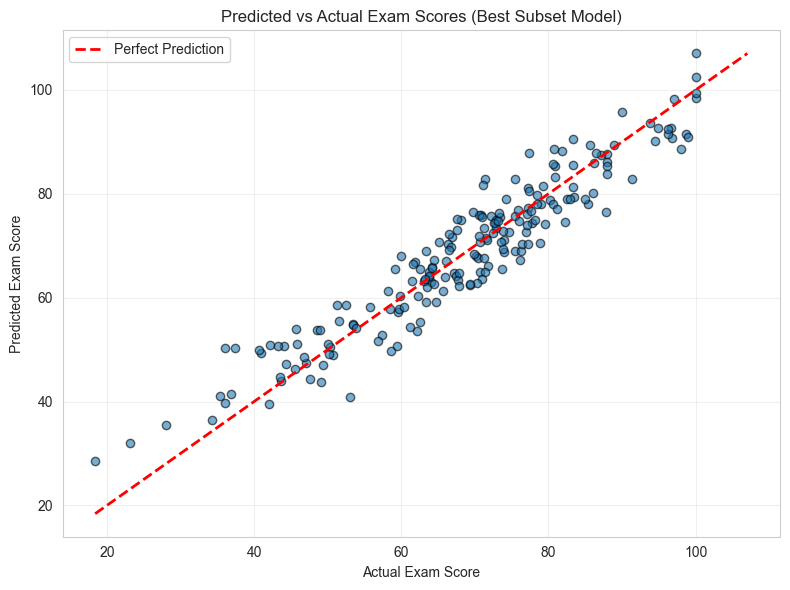

In [81]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_bs, y_pred_bs, alpha=0.6, edgecolors='black')

min_val = min(np.min(y_test_bs), np.min(y_pred_bs))
max_val = max(np.max(y_test_bs), np.max(y_pred_bs))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title('Predicted vs Actual Exam Scores (Best Subset Model)')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('figures/predicted_vs_actual_best_subset.png', dpi=300)
plt.show()


# **Residual Plot**

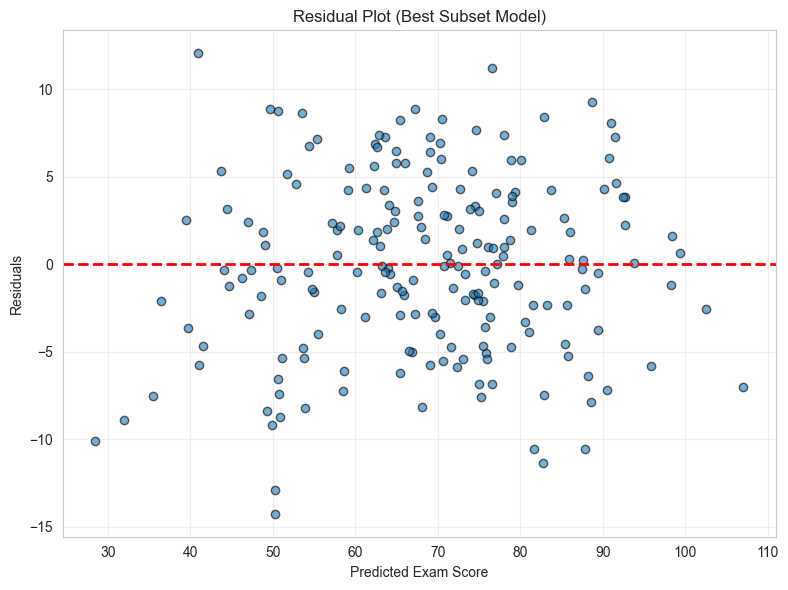

In [82]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_bs, residuals_bs, alpha=0.6, edgecolors='black')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Best Subset Model)')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('figures/residual_plot_best_subset.png', dpi=300)
plt.show()


# **11.3 Best Baseline Model Summary**

In [77]:
print("Best Baseline Regression Model")
print("-" * 40)
print("Model:", best_baseline["Approach"])
print("R2:", round(best_baseline["R2"], 4))
print("Adjusted R2:", round(best_baseline["Adjusted R2"], 4))
print("MAE:", round(best_baseline["MAE"], 4))
print("RMSE:", round(best_baseline["RMSE"], 4))
print("CV R2:", round(best_baseline["CV R2"], 4))


Best Baseline Regression Model
----------------------------------------
Model: Lasso Regression
R2: 0.8982
Adjusted R2: 0.8905
MAE: 4.1506
RMSE: 5.1096
CV R2: 0.897


# **11.4 Best Feature Selection Method Summary**

In [78]:
print("Best Feature Selection Method")
print("-" * 40)
print("Method:", best_feature_selection["Approach"])
print("R2:", round(best_feature_selection["R2"], 4))
print("Adjusted R2:", round(best_feature_selection["Adjusted R2"], 4))
print("MAE:", round(best_feature_selection["MAE"], 4))
print("RMSE:", round(best_feature_selection["RMSE"], 4))
print("CV R2:", round(best_feature_selection["CV R2"], 4))
print("Number of Features:", best_feature_selection["Num Features"])


Best Feature Selection Method
----------------------------------------
Method: Best Subset Selection
R2: 0.8996
Adjusted R2: 0.8959
MAE: 4.1139
RMSE: 5.0745
CV R2: 0.8975
Number of Features: 7


# **11.5 Automatic Conclusion Text**

In [79]:
conclusion_text = f"""
Conclusion

The objective of this project was to predict students' exam scores using demographic, lifestyle,
behavioral, and academic features.

After exploring the dataset, preprocessing was applied by removing the identifier column, scaling
numerical variables, and encoding categorical variables. Three baseline regression models were trained:
Linear Regression, Ridge Regression, and Lasso Regression.

In addition, four model selection methods were implemented:
Forward Selection, Backward Elimination, Hybrid Selection, and Best Subset Selection.

Based on the final comparison, the best overall approach was {best_overall["Approach"]} from the
{best_overall["Category"]} category.

This approach achieved:
- R2 = {best_overall["R2"]:.4f}
- Adjusted R2 = {best_overall["Adjusted R2"]:.4f}
- MAE = {best_overall["MAE"]:.4f}
- RMSE = {best_overall["RMSE"]:.4f}
- CV R2 = {best_overall["CV R2"]:.4f}

Overall, the results show that this model provided the best balance between predictive accuracy
and generalization performance.
"""

print(conclusion_text)



Conclusion

The objective of this project was to predict students' exam scores using demographic, lifestyle,
behavioral, and academic features.

After exploring the dataset, preprocessing was applied by removing the identifier column, scaling
numerical variables, and encoding categorical variables. Three baseline regression models were trained:
Linear Regression, Ridge Regression, and Lasso Regression.

In addition, four model selection methods were implemented:
Forward Selection, Backward Elimination, Hybrid Selection, and Best Subset Selection.

Based on the final comparison, the best overall approach was Best Subset Selection from the
Feature Selection category.

This approach achieved:
- R2 = 0.8996
- Adjusted R2 = 0.8959
- MAE = 4.1139
- RMSE = 5.0745
- CV R2 = 0.8975

Overall, the results show that this model provided the best balance between predictive accuracy
and generalization performance.



Conclusion

The objective of this project was to predict students' exam scores using demographic, lifestyle,
behavioral, and academic features.

After exploring the dataset, preprocessing was applied by removing the identifier column, scaling
numerical variables, and encoding categorical variables. Three baseline regression models were trained:
Linear Regression, Ridge Regression, and Lasso Regression.

In addition, four model selection methods were implemented:
Forward Selection, Backward Elimination, Hybrid Selection, and Best Subset Selection.

Based on the final comparison, the best overall approach was Best Subset Selection from the
Feature Selection category.

This approach achieved:
- R2 = 0.8996
- Adjusted R2 = 0.8959
- MAE = 4.1139
- RMSE = 5.0745
- CV R2 = 0.8975

Overall, the results show that this model provided the best balance between predictive accuracy
and generalization performance.
